<a href="https://colab.research.google.com/github/Suvanga/ML_DL/blob/main/Model_0_From_Scratch.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##Imports
`torch`
`matplotlib`
`numpy`
`pandas`



![image.png]()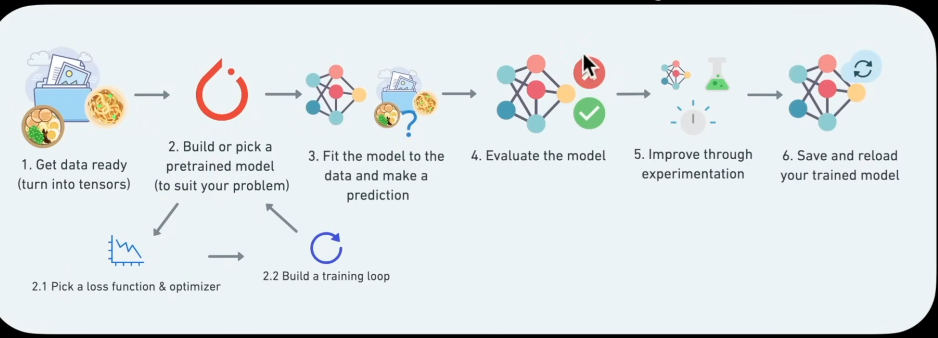

In [75]:
import torch
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from torch import nn #nn contains all of the pytorch building blocks



##Creating a raw Data


In [76]:
Weights = 0.7
Bias = 0.3
Step = 0.02
X = torch.arange(0.0,1.0,Step).unsqueeze(dim = 1)
y = Weights*X + Bias


##Setting up device agnostic code

In [77]:
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cpu'

##Splitting the training and testing data

In [78]:
#80% for train and 20% for test
train_split = int(0.8*len(X))
train_X = X[:train_split]
train_y = y[:train_split]
test_X = X[train_split:]
test_y = y[train_split:]


In [79]:
##Making a method for plotting predictions so that it will br easier later

def plot_predictions(predictions):
  plt.figure(figsize = (10,7))
  plt.scatter(train_X,train_y,c = "b",s = 4,label = "Training Data")
  plt.scatter(test_X,test_y,c = "g",s = 4,label = "Testing Data")
  if predictions is not None:
    plt.scatter(test_X,predictions,c = "r",s = 4,label = "Predictions")
  plt.legend(prop = {"size":14})


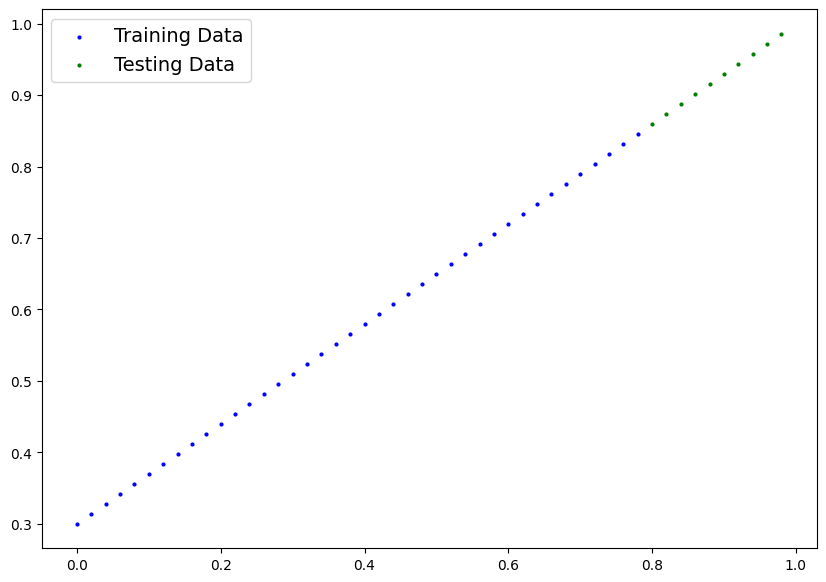

In [80]:
plot_predictions(predictions = None)

##Making a model for training and testing
1. This is what the weight and bias we selected would look like if we put it in code persppective
  *   `self.weights = torch.nn.Parameter(torch.randn(1, requires_grad=True, dtype=torch.float32))
  self.bias = torch.nn.Parameter(torch.randn(1, requires_grad=True, dtype=torch.float32))`
  * Replaced by :
      `self.linear_layer = nn.Linear(in_features = 1,  out_features= 1)`
* Look at Pytorch.nn to look at all the layers available to built, here we are using a linear model as a layer and that is how DL works... with lots of layers



In [81]:

torch.manual_seed(42)
class Linear_Regression_Model(nn.Module):
  def __init__(self):
    super().__init__()
    self.linear_layer = nn.Linear(in_features = 1, out_features= 1)


  def forward(self, x: torch.Tensor)->torch.Tensor:
    return self.linear_layer(x)



##Initializing a model


In [82]:
# to make it uniform we can use a random seed of 42
torch.manual_seed(42)
from typing import List
model_0 = Linear_Regression_Model()
list(model_0.parameters()) #visualize the data

[Parameter containing:
 tensor([[0.7645]], requires_grad=True),
 Parameter containing:
 tensor([0.8300], requires_grad=True)]

In [83]:
model_0.to(device)

Linear_Regression_Model(
  (linear_layer): Linear(in_features=1, out_features=1, bias=True)
)

##Creating Loss L1 AKA Cost Function to calculate MSE AKA cost Function


In [84]:
#loss and optimizer
loss = torch.nn.L1Loss()



##Creating an Optimizer

In [85]:
optim = torch.optim.SGD(params = model_0.parameters() ,lr =0.01) #parameters refers to thte things that we want the gradient descent to reflect up on

In [86]:
##Crrating a Training Loop
torch.manual_seed(42)

epochs = 200

for epoch in range(epochs):
  model_0.train()

  #forward pass
  y_pred = model_0(train_X)
  #loss calculation
  l = loss(y_pred,train_y)
  #optimizer grad set to 0
  optim.zero_grad()
  #Backward propagation
  l.backward()
  #Gradient descent
  optim.step()


  #testing
  #TESTING

  model_0.eval()
  with torch.inference_mode():
    test_pred = model_0(test_X)

    test_loss = loss(test_pred, test_y)

    if epoch%10 ==0:
      print(f"Epoch: {epoch} | Loss : {l} | TestLoss : {test_loss}")



Epoch: 0 | Loss : 0.5551779866218567 | TestLoss : 0.5739762187004089
Epoch: 10 | Loss : 0.4399680495262146 | TestLoss : 0.4392663538455963
Epoch: 20 | Loss : 0.3247582018375397 | TestLoss : 0.30455657839775085
Epoch: 30 | Loss : 0.20954827964305878 | TestLoss : 0.16984674334526062
Epoch: 40 | Loss : 0.09433844685554504 | TestLoss : 0.03513689711689949
Epoch: 50 | Loss : 0.023886386305093765 | TestLoss : 0.04784906655550003
Epoch: 60 | Loss : 0.0199567973613739 | TestLoss : 0.04580312222242355
Epoch: 70 | Loss : 0.016517987474799156 | TestLoss : 0.0375305712223053
Epoch: 80 | Loss : 0.013089170679450035 | TestLoss : 0.029944902285933495
Epoch: 90 | Loss : 0.009653178043663502 | TestLoss : 0.02167237363755703
Epoch: 100 | Loss : 0.006215679459273815 | TestLoss : 0.014086711220443249
Epoch: 110 | Loss : 0.002787243574857712 | TestLoss : 0.005814164876937866
Epoch: 120 | Loss : 0.0012645035749301314 | TestLoss : 0.013801807537674904
Epoch: 130 | Loss : 0.0012645035749301314 | TestLoss : 0.

In [87]:
model_0.state_dict()

OrderedDict([('linear_layer.weight', tensor([[0.6968]])),
             ('linear_layer.bias', tensor([0.3025]))])

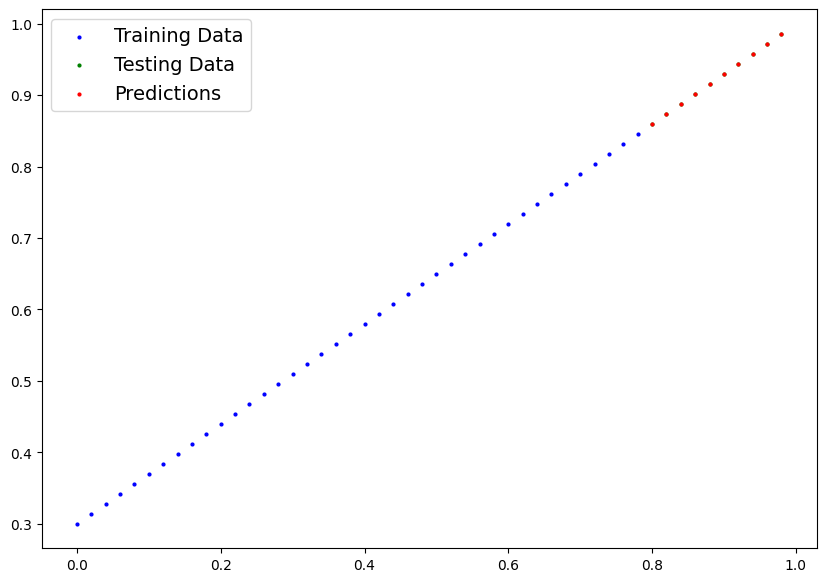

In [89]:
with torch.inference_mode():
  test_pred = model_0(test_X)
plot_predictions(predictions =  test_pred )

##Saving and loading model

In [92]:
from pathlib import Path

##create models directory


In [99]:


MODEL_PATH = Path("models")
MODEL_PATH.mkdir(parents = True, exist_ok = True)



 ## naming it

In [101]:
Model_name = "01_potorch_Workflow.pth"
Model_Save_Path = MODEL_PATH/Model_name


##Saving the important information AKA state of the model

In [102]:
torch.save(obj = model_0.state_dict(),f = Model_Save_Path)

In [103]:
model_0.state_dict()

OrderedDict([('linear_layer.weight', tensor([[0.6968]])),
             ('linear_layer.bias', tensor([0.3025]))])

#Loading the model
1. Creating a new instance
2. Loading a new statedicgt into that model

In [106]:
loaded_model_1 = Linear_Regression_Model()

In [107]:
loaded_model_1.load_state_dict(torch.load(Model_Save_Path))

<All keys matched successfully>

In [108]:
loaded_model_1.to(device)

Linear_Regression_Model(
  (linear_layer): Linear(in_features=1, out_features=1, bias=True)
)

In [109]:
model_0.state_dict()

OrderedDict([('linear_layer.weight', tensor([[0.6968]])),
             ('linear_layer.bias', tensor([0.3025]))])

In [110]:
loaded_model_1.state_dict()

OrderedDict([('linear_layer.weight', tensor([[0.6968]])),
             ('linear_layer.bias', tensor([0.3025]))])

In [112]:
##Evaluating the loaded model
loaded_model_1.eval()
with torch.inference_mode():
  Loaded_preds = loaded_model_1(test_X)
test_pred == Loaded_preds


tensor([[True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True]])